# tinyNeRF from COLMAP Reconstruction

Based on https://www.youtube.com/watch?v=eW9wX_ruSaE

## Imports

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.init as init
import time
import numpy as np
import os
from tqdm import tqdm
from ipywidgets import interactive, widgets
import torch.nn.functional as F

## Encoding

In [2]:
def encoding(x, L=10):
  res = [x]
  for i in range(L):
    for fn in [torch.sin, torch.cos]:
      res.append(fn(2 ** i * torch.pi * x))
  return torch.cat(res,dim=-1)

## Model

In [3]:
class NeRF(nn.Module):
  def __init__(self, pos_enc_dim=63, view_enc_dim=27, hidden=256) -> None:
     super().__init__()

     self.linear1 = nn.Sequential(nn.Linear(pos_enc_dim,hidden),nn.ReLU())

     self.pre_skip_linear = nn.Sequential()
     for _ in range(4):
      self.pre_skip_linear.append(nn.Linear(hidden,hidden))
      self.pre_skip_linear.append(nn.ReLU())

     self.linear_skip = nn.Sequential(nn.Linear(pos_enc_dim+hidden,hidden),nn.ReLU())

     self.post_skip_linear = nn.Sequential()
     for _ in range(2):
      self.post_skip_linear.append(nn.Linear(hidden,hidden))
      self.post_skip_linear.append(nn.ReLU())

     self.density_layer = nn.Sequential(nn.Linear(hidden,1),nn.ReLU())

     self.linear2 = nn.Linear(hidden,hidden)

     self.color_linear1 = nn.Sequential(nn.Linear(hidden+view_enc_dim,hidden//2),nn.ReLU())
     self.color_linear2 = nn.Sequential(nn.Linear(hidden//2,3),nn.Sigmoid())

  def forward(self, input):

    positions = input[...,:3]
    view_dirs = input[...,3:]

    # Encode
    pos_enc = encoding(positions,L=10)
    view_enc = encoding(view_dirs,L=4)

    x = self.linear1(pos_enc)
    x = self.pre_skip_linear(x)

    # Skip connection
    x = torch.cat([x,pos_enc],dim=-1)
    x = self.linear_skip(x)

    x = self.post_skip_linear(x)

    # Density
    sigma = self.density_layer(x)

    x = self.linear2(x)

    # View Encoding
    x = torch.cat([x,view_enc],dim=-1)
    x = self.color_linear1(x)

    # Color Prediction
    rgb = self.color_linear2(x)

    return torch.cat([sigma,rgb],dim=-1)


## Get Rays

In [4]:
def get_rays(H, W, focal, c2w):
  """
  Generate rays for a given camera configuration.

  Args:
    H: Image height.
    W: Image width.
    focal: Focal length.
    c2w: Camera-to-world transformation matrix (4x4).

  Returns:
    rays_o: Ray origins (H*W, 3).
    rays_d: Ray directions (H*W, 3).
  """
  device = c2w.device  # Get the device of c2w
  focal = torch.from_numpy(focal).to(device)
  # print(type(H), type(W), type(focal), type(c2w))

  i, j = torch.meshgrid(
      torch.arange(W, dtype=torch.float32, device=device),
      torch.arange(H, dtype=torch.float32, device=device),
      indexing='xy'
  )
  dirs = torch.stack(
      [(i - W * .5) / focal, -(j - H * .5) / focal, -torch.ones_like(i, device = device)], -1
  )

  rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)
  rays_d = rays_d.view(-1, 3)
  rays_o = c2w[:3, -1].expand(rays_d.shape)

  return rays_o, rays_d

## Render Rays

In [5]:
def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, device, rand=False, embed_fn=None, chunk=1024*4):
    def batchify(fn, chunk):
        return lambda inputs: torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)

    # Sampling
    z_vals = torch.linspace(near, far, steps=N_samples, device=device)

    if rand:
        z_vals += torch.rand(*z_vals.shape[:-1], N_samples, device=rays_o.device) * (far - near) / N_samples

    pts = rays_o[...,None,:] + rays_d[...,None,:] * z_vals[...,:,None]

    # Normalize view directions
    view_dirs = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)
    view_dirs = view_dirs[..., None, :].expand(pts.shape)

    input_pts = torch.cat((pts, view_dirs), dim=-1)
    raw = batchify(network_fn, chunk)(input_pts)

    # Apply activations here instead of in network
    sigma_a = raw[...,0]  # Shape: [batch, N_samples]
    rgb = raw[...,1:]    # Shape: [batch, N_samples, 3]

    # Improved volume rendering
    dists = z_vals[..., 1:] - z_vals[..., :-1]  # Shape: [batch, N_samples-1]
    dists = torch.cat([dists, torch.tensor([1e10], device=device)], -1)

    # No need to manually expand dists as broadcasting will handle it
    alpha = 1. - torch.exp(-sigma_a * dists)  # Shape: [batch, N_samples]
    alpha = alpha.unsqueeze(-1)  # Shape: [batch, N_samples, 1]

    # Computing transmittance
    ones_shape = (alpha.shape[0], 1, 1)
    T = torch.cumprod(
        torch.cat([
            torch.ones(ones_shape, device=device),
            1. - alpha + 1e-10
        ], dim=1),
        dim=1
    )[:, :-1]  # Shape: [batch, N_samples, 1]

    weights = alpha * T  # Shape: [batch, N_samples, 1]

    # Compute final colors and depths
    rgb_map = torch.sum(weights * rgb, dim=1)  # Sum along sample dimension
    depth_map = torch.sum(weights.squeeze(-1) * z_vals, dim=-1)  # Shape: [batch]
    acc_map = torch.sum(weights.squeeze(-1), dim=-1)  # Shape: [batch]

    return rgb_map, depth_map, acc_map

## Load Data

(102, 100, 100, 3) (102, 4, 4) 3276.8159026144594 100 100
Using device: cuda
Pose example:
 [[-0.9837933  -0.08766475  0.15641484 -0.64229643]
 [-0.01688573  0.9137528   0.40591958 -0.8966648 ]
 [-0.17850934  0.3966998  -0.9004242   3.7480085 ]
 [ 0.          0.          0.          1.        ]]


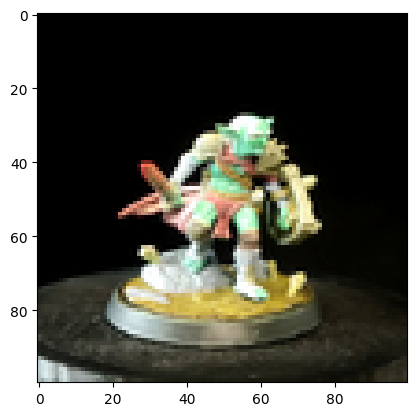

In [9]:
import sys
sys.path.append("../utils")
from colmap import load_nerf_data_from_colmap

train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/1",
    images_dir = "../data/images",
    image_size = (100, 100), # optional resize
)
H, W = train_images.shape[1:3]
print(train_images.shape, train_poses.shape, focal, H, W)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Pose example:\n", train_poses[0])
plt.imshow(test_images[0])
plt.show()
focal = np.array(focal)
testimg = torch.from_numpy(test_images[0]).float().to(device)
testpose = torch.from_numpy(test_poses[0]).float().to(device)

## Train Model

In [7]:
n_iter = 20000
n_samples = 64
i_plot = 100

def train(images, poses, H, W, focal, testpose, testimg, device):
    print(f"Using device: {device}")
    model = NeRF().to(device)
   
    criterion = nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
    
    use_amp = (device == "cuda" and torch.cuda.is_available())
    scaler = torch.cuda.amp.GradScaler()

    psnrs = []
    iternums = []
    t = time.time()

    plots_folder = '../results/nerf'
    os.makedirs(plots_folder, exist_ok=True)

    images_tensor = torch.from_numpy(images).float().to(device)
    poses_tensor = torch.from_numpy(poses).float().to(device)

    for i in tqdm(range(n_iter), desc="Training NeRF", unit="iter"):
        img_i = np.random.randint(images.shape[0])
        target = images_tensor[img_i]
        pose = poses_tensor[img_i]

        rays_o, rays_d = get_rays(H, W, focal, pose)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            rgb, depth, _ = render_rays(
                model, rays_o, rays_d, near=2., far=6.,
                N_samples=n_samples, device=device, rand=True
            )
            rgb = rgb.reshape(H, W, 3)
            loss = criterion(rgb, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if i % i_plot == 0:
            print(f'Iteration: {i}, Loss: {loss.item():.6f}, Time: {(time.time() - t) / max(i, 1):.2f} secs per iter')
            t = time.time()

            with torch.no_grad():
                rays_o, rays_d = get_rays(H, W, focal, testpose)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    rgb, depth, _ = render_rays(
                        model, rays_o, rays_d, near=2., far=6.,
                        N_samples=n_samples, device=device
                    )
                    rgb = rgb.reshape(H, W, 3)
                    val_loss = criterion(rgb, testimg)

                psnr = -10. * torch.log10(val_loss.float())
                psnrs.append(psnr.item())
                iternums.append(i)

                plt.figure(figsize=(15, 5))
                plt.subplot(131)
                plt.imshow(rgb.detach().float().cpu())
                plt.title(f'Iteration: {i}')
                plt.subplot(132)
                plt.plot(iternums, psnrs)
                plt.title('PSNR')
                plt.xlabel('Iteration')
                plt.ylabel('PSNR')
                plt.subplot(133)
                plt.imshow(depth.detach().float().cpu().reshape(H, W), cmap='viridis')
                plt.title('Depth Map')
                plt.colorbar()

                plot_path = os.path.join(plots_folder, f'iter_{i:05d}.png')
                plt.savefig(plot_path)
                plt.close()
                print(f'[INFO] Plot saved to {plot_path}')

    return model

In [10]:
model = train(train_images, train_poses, H, W, focal, testpose, testimg, device)

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_34928\1496073090.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Using device: cuda


Training NeRF:   0%|          | 0/20000 [00:00<?, ?iter/s]C:\Users\gnoceras\AppData\Local\Temp\ipykernel_34928\1496073090.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Iteration: 0, Loss: 0.199277, Time: 0.87 secs per iter


Training NeRF:   0%|          | 1/20000 [00:01<6:31:35,  1.17s/iter]

...

Iteration: 1200, Loss: 0.063926, Time: 0.03 secs per iter


Training NeRF:   6%|▌         | 1201/20000 [06:38<2:32:07,  2.06iter/s]

[INFO] Plot saved to ../results/nerf\iter_01200.png


Training NeRF:   6%|▋         | 1288/20000 [07:07<1:43:26,  3.01iter/s]


KeyboardInterrupt: 

## Render Video

In [9]:
# Transformation matrices in PyTorch
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi), torch.cos(phi), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0, torch.cos(th), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

# Pose function with spherical coordinates
def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = torch.matmul(rot_phi(torch.Tensor([phi / 180. * np.pi])), c2w)
    c2w = torch.matmul(rot_theta(torch.Tensor([theta / 180. * np.pi])), c2w)
    c2w = torch.tensor([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=torch.float32) @ c2w
    return c2w

# Function for rendering based on user input
def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])  # Get rays (this is a placeholder)
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device=device)  # Render rays
    rgb = rgb.reshape(H, W, 3).cpu().detach()
    img = torch.clamp(rgb, 0, 1).numpy()  # Clamp RGB values between 0 and 1 and convert to numpy

    plt.figure(2, figsize=(20, 6))
    plt.imshow(img)
    plt.show()

# Interactive slider setup for theta, phi, and radius
sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [ ]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device = device)
    rgb = rgb.reshape(H, W, 3)
    frames.append((255*np.clip(rgb.cpu().detach().numpy(),0,1)).astype(np.uint8))

In [13]:
import imageio
f = '../results/nerf/video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (100, 100) to (112, 112) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [15]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('../results/nerf/video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)